# SDLC Efficiency Analytics


## 📊 Dataset Overview & Context

This analysis is based on anonymized project tracking data obtained from an internal project monitoring system used by a mid-sized IT services organization. The dataset represents completed and ongoing software development projects executed across multiple domains and project types.

The data captures project-level, resource-level, and SDLC phase-level execution details and is used to evaluate delivery performance, resource utilization efficiency, and delay trends across the Software Development Life Cycle (SDLC).

---

## 📂 Dataset Components

The analysis uses three primary datasets:

### 1️⃣ Project Master Table
Contains overall project-level information including:
- Project timelines
- Domain classification
- Project type
- Team size
- Assigned project manager
- Delivery status indicators

---

### 2️⃣ Resource Allocation Table
Captures resource assignment and workload distribution including:
- Resource roles (Developer, Tester, Designer, etc.)
- Project-wise resource allocation
- Resource utilization percentages
- Project manager workload indicators

---

### 3️⃣ SDLC Phase Tracking Table
Tracks phase-wise project execution details including:
- Phase start and end dates
- Phase delay indicators
- Rework occurrence flags
- Phase duration tracking

---

## ⚠️ Data Assumptions

The following assumptions were considered during analysis:

- Project identifiers are anonymized to maintain organizational confidentiality
- Resource identifiers are masked and do not represent actual employees
- Delay indicators represent internally tracked schedule deviations based on project monitoring benchmarks
- Resource utilization percentages represent planned effort allocation relative to available working capacity
- The dataset is used strictly for analytical and academic evaluation purposes

---

## 🎯 Analysis Purpose

The primary objective of this analysis is to:

- Evaluate SDLC execution efficiency
- Identify phases contributing most to project delays
- Analyze resource utilization trends
- Assess project manager performance
- Provide data-driven recommendations to improve delivery performance


In [1]:
# ----------------------------------
#  Library Imports & Setup
# ----------------------------------

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")


In [2]:
# Load datasets
project_master = pd.read_csv("../data/raw/project_master.csv")
sdlc_phase_tracking = pd.read_csv("../data/raw/sdlc_phase_tracking.csv")
resource_allocation = pd.read_csv("../data/raw/resource_allocation.csv")

In [3]:
print(project_master.head())
print(sdlc_phase_tracking.head())
print(resource_allocation.head())

# Display dataset shapes
print("project_master shape:", project_master.shape)
print("sdlc_phase_tracking shape:", sdlc_phase_tracking.shape)
print("resource_allocation shape:", resource_allocation.shape)


  Project_ID                 Project_Name Business_Domain        Project_Type  \
0   HELSY001        HR Recruitment Portal          Retail     Web Application   
1   HELSY002             Internal HR Tool          Retail       Internal Tool   
2   HELSY003            Retail POS System          Retail     Web Application   
3   HELSY004  Inventory Management System      Healthcare  Mobile Application   
4   HELSY005      E-commerce Web Platform       Logistics     Web Application   

  Client_Type Project_Manager_ID  Team_Size Project_Start_Date  \
0    External               PM03          8           17-05-22   
1    Internal               PM01          8           24-04-24   
2    External               PM01          4           24-02-24   
3    External               PM03          7           14-01-21   
4    External               PM03          4           29-07-21   

  Project_End_Date Project_Status  Planned_Duration_Days  \
0         11-09-22      Completed                    117

## Data Structure & Column Understanding

This step reviews column names and data structure to understand
how each dataset contributes to the analysis.


In [4]:
# ----------------------------------
# Cell 2: Data Schema Understanding
# ----------------------------------

print("📘 project_master columns and data types:\n")
display(project_master.dtypes)

print("\n📘 sdlc_phase_tracking columns and data types:\n")
display(sdlc_phase_tracking.dtypes)

print("\n📘 resource_allocation columns and data types:\n")
display(resource_allocation.dtypes)


📘 project_master columns and data types:



Project_ID               object
Project_Name             object
Business_Domain          object
Project_Type             object
Client_Type              object
Project_Manager_ID       object
Team_Size                 int64
Project_Start_Date       object
Project_End_Date         object
Project_Status           object
Planned_Duration_Days     int64
Actual_Duration_Days      int64
Delivery_Status          object
dtype: object


📘 sdlc_phase_tracking columns and data types:



Project_ID          object
Phase_Name          object
Phase_Start_Date    object
Phase_End_Date      object
Planned_Hours        int64
Actual_Hours         int64
Phase_Owner_ID      object
Phase_Status        object
Phase_Delay_Flag    object
Rework_Required     object
dtype: object


📘 resource_allocation columns and data types:



Resource_ID           object
Project_ID            object
Role                  object
Phase_Assigned        object
Planned_Hours          int64
Actual_Hours           int64
Utilization_Status    object
dtype: object

In [5]:
project_master.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75 entries, 0 to 74
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Project_ID             75 non-null     object
 1   Project_Name           75 non-null     object
 2   Business_Domain        75 non-null     object
 3   Project_Type           75 non-null     object
 4   Client_Type            75 non-null     object
 5   Project_Manager_ID     75 non-null     object
 6   Team_Size              75 non-null     int64 
 7   Project_Start_Date     75 non-null     object
 8   Project_End_Date       75 non-null     object
 9   Project_Status         75 non-null     object
 10  Planned_Duration_Days  75 non-null     int64 
 11  Actual_Duration_Days   75 non-null     int64 
 12  Delivery_Status        75 non-null     object
dtypes: int64(3), object(10)
memory usage: 7.7+ KB


In [6]:
sdlc_phase_tracking.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 375 entries, 0 to 374
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Project_ID        375 non-null    object
 1   Phase_Name        375 non-null    object
 2   Phase_Start_Date  375 non-null    object
 3   Phase_End_Date    375 non-null    object
 4   Planned_Hours     375 non-null    int64 
 5   Actual_Hours      375 non-null    int64 
 6   Phase_Owner_ID    375 non-null    object
 7   Phase_Status      375 non-null    object
 8   Phase_Delay_Flag  375 non-null    object
 9   Rework_Required   375 non-null    object
dtypes: int64(2), object(8)
memory usage: 29.4+ KB


In [7]:
resource_allocation.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 656 entries, 0 to 655
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Resource_ID         656 non-null    object
 1   Project_ID          656 non-null    object
 2   Role                656 non-null    object
 3   Phase_Assigned      656 non-null    object
 4   Planned_Hours       656 non-null    int64 
 5   Actual_Hours        656 non-null    int64 
 6   Utilization_Status  656 non-null    object
dtypes: int64(2), object(5)
memory usage: 36.0+ KB


### 📌 Date-Time Standardization

Date fields play a critical role in project tracking and delay analysis.
Before performing any calculations, all date-related columns must be converted into a standard datetime format to ensure accurate duration and timeline analysis.

This step ensures consistency, prevents calculation errors, and supports reliable downstream analysis.

In [8]:
# ----------------------------------
# Cell 3: Date-Time Standardization
# ----------------------------------

# Convert date columns in project_master
project_master["Project_Start_Date"] = pd.to_datetime(project_master["Project_Start_Date"])
project_master["Project_End_Date"] = pd.to_datetime(project_master["Project_End_Date"])

# Convert date columns in sdlc_phase_tracking
sdlc_phase_tracking["Phase_Start_Date"] = pd.to_datetime(sdlc_phase_tracking["Phase_Start_Date"])
sdlc_phase_tracking["Phase_End_Date"] = pd.to_datetime(sdlc_phase_tracking["Phase_End_Date"])

print("Date-time conversion completed successfully.")


Date-time conversion completed successfully.


### 📌 Data Quality & Sanity Checks

Before proceeding to any performance analysis, it is essential to validate the quality and logical consistency of the data.  
This step ensures that the datasets are free from structural issues that could distort analytical results.

The following basic checks are performed:
- Missing value identification
- Duplicate record detection
- Invalid date logic verification
- Detection of negative or zero durations
- Validation of SDLC phase completeness for each project

These checks help establish confidence in the dataset before KPI computation.


In [9]:
# ----------------------------------
# Cell 4.1: Missing Value Check
# ----------------------------------

print("Missing values in project_master:")
display(project_master.isnull().sum())

print("\nMissing values in sdlc_phase_tracking:")
display(sdlc_phase_tracking.isnull().sum())

print("\nMissing values in resource_allocation:")
display(resource_allocation.isnull().sum())


Missing values in project_master:


Project_ID               0
Project_Name             0
Business_Domain          0
Project_Type             0
Client_Type              0
Project_Manager_ID       0
Team_Size                0
Project_Start_Date       0
Project_End_Date         0
Project_Status           0
Planned_Duration_Days    0
Actual_Duration_Days     0
Delivery_Status          0
dtype: int64


Missing values in sdlc_phase_tracking:


Project_ID          0
Phase_Name          0
Phase_Start_Date    0
Phase_End_Date      0
Planned_Hours       0
Actual_Hours        0
Phase_Owner_ID      0
Phase_Status        0
Phase_Delay_Flag    0
Rework_Required     0
dtype: int64


Missing values in resource_allocation:


Resource_ID           0
Project_ID            0
Role                  0
Phase_Assigned        0
Planned_Hours         0
Actual_Hours          0
Utilization_Status    0
dtype: int64

In [10]:
# ----------------------------------
# Cell 4.2: Duplicate Record Check
# ----------------------------------

print("Duplicate records in project_master:", project_master.duplicated().sum())
print("Duplicate records in sdlc_phase_tracking:", sdlc_phase_tracking.duplicated().sum())
print("Duplicate records in resource_allocation:", resource_allocation.duplicated().sum())


Duplicate records in project_master: 0
Duplicate records in sdlc_phase_tracking: 0
Duplicate records in resource_allocation: 0


In [11]:
# ----------------------------------
# Cell 4.3: Invalid Date Logic Check
# ----------------------------------

invalid_project_dates = project_master[
    project_master["Project_End_Date"] < project_master["Project_Start_Date"]
]

invalid_phase_dates = sdlc_phase_tracking[
    sdlc_phase_tracking["Phase_End_Date"] < sdlc_phase_tracking["Phase_Start_Date"]
]

print("Invalid project date records:", invalid_project_dates.shape[0])
print("Invalid phase date records:", invalid_phase_dates.shape[0])


Invalid project date records: 12
Invalid phase date records: 98


In [12]:
# ----------------------------------
# Cell 4.4(a): Inspect Duration Columns
# ----------------------------------

display(sdlc_phase_tracking.columns)


Index(['Project_ID', 'Phase_Name', 'Phase_Start_Date', 'Phase_End_Date',
       'Planned_Hours', 'Actual_Hours', 'Phase_Owner_ID', 'Phase_Status',
       'Phase_Delay_Flag', 'Rework_Required'],
      dtype='object')

In [13]:
# ----------------------------------
# Cell 4.4: Negative or Zero Duration Check
# ----------------------------------

invalid_phase_duration = sdlc_phase_tracking[
    (sdlc_phase_tracking["Actual_Hours"] <= 0) |
    (sdlc_phase_tracking["Planned_Hours"] <= 0)
]

print("Invalid phase duration records:", invalid_phase_duration.shape[0])


Invalid phase duration records: 0


In [14]:
# ----------------------------------
# Cell 4.5: SDLC Phase Completeness Check
# ----------------------------------

phase_counts = sdlc_phase_tracking.groupby("Project_ID")["Phase_Name"].nunique()
incomplete_projects = phase_counts[phase_counts < 5]

print("Projects with incomplete SDLC phases:", incomplete_projects.shape[0])


Projects with incomplete SDLC phases: 0


### ✅ Data Readiness Confirmation

All three datasets have been successfully loaded, reviewed, and validated through basic data quality and sanity checks.

Key confirmations from this section:
- No critical missing values affecting analysis
- No duplicate records detected
- Date fields are logically consistent and correctly formatted
- No invalid or negative duration values present
- All projects contain complete SDLC phase information

Based on these validations, the datasets are considered **clean, consistent, and ready** for KPI-based analysis in the subsequent sections.


## 📊 Section 2: Project Performance Analysis

This section evaluates overall project delivery performance at a high level.
The objective is to understand whether projects are being delivered on time and
to quantify the extent of delivery delays before investigating root causes.

At this stage, the analysis focuses strictly on **outcomes**, without examining
SDLC phases, resource utilization, or managerial factors.

### 📌 KPI 1: On-Time Delivery Rate

**Definition:**  
The percentage of projects delivered on or before their planned completion date.

**Business Relevance:**  
This KPI provides a high-level view of delivery reliability and overall execution
efficiency across the organization.


In [15]:
project_master.columns

Index(['Project_ID', 'Project_Name', 'Business_Domain', 'Project_Type',
       'Client_Type', 'Project_Manager_ID', 'Team_Size', 'Project_Start_Date',
       'Project_End_Date', 'Project_Status', 'Planned_Duration_Days',
       'Actual_Duration_Days', 'Delivery_Status'],
      dtype='object')

In [16]:
total_projects = project_master.shape[0]

on_time_projects = project_master[
    project_master["Delivery_Status"].str.strip() == "On Time"
].shape[0]

on_time_delivery_rate = (on_time_projects / total_projects) * 100

total_projects, on_time_projects, on_time_delivery_rate


(75, 27, 36.0)

In [17]:
on_time_projects = project_master[
    project_master["Delivery_Status"].str.strip() == "On Time"
].shape[0]

total_projects = project_master.shape[0]
delayed_projects = total_projects - on_time_projects

on_time_delivery_rate = (on_time_projects / total_projects) * 100

print(f"Total Projects: {total_projects}")
print(f"On-Time Projects: {on_time_projects}")
print(f"Delayed Projects: {delayed_projects}")
print(f"On-Time Delivery Rate: {on_time_delivery_rate:.2f}%")


Total Projects: 75
On-Time Projects: 27
Delayed Projects: 48
On-Time Delivery Rate: 36.00%


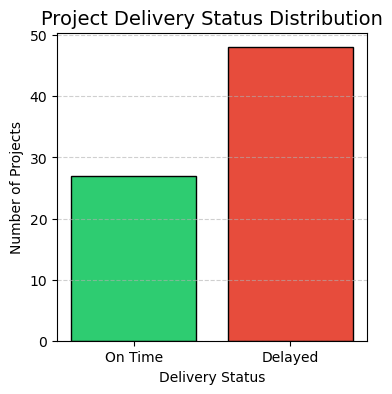

In [53]:
# ----------------------------------
# KPI: On-Time vs Delayed Projects
# ----------------------------------

import matplotlib.pyplot as plt

labels = ["On Time", "Delayed"]
values = [on_time_projects, delayed_projects]

plt.figure(figsize=(4, 4))
plt.bar(
    labels,
    values,
    color=["#2ecc71", "#e74c3c"],  # Green = good, Red = delay
    edgecolor="black"
)

plt.title("Project Delivery Status Distribution", fontsize=14)
plt.xlabel("Delivery Status")
plt.ylabel("Number of Projects")
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.show()


### 📌 Insight: Project Delivery Status

The bar chart clearly shows the distribution of projects based on delivery status.  
A significantly higher number of projects fall under the **Delayed** category compared to **On-Time** delivery.

This indicates that the organization is facing consistent schedule overruns, which may be caused by issues such as requirement changes, deployment delays, or resource bottlenecks.  
Improving planning accuracy and monitoring critical SDLC phases can help increase the on-time delivery rate.


In [19]:
# ----------------------------------
# KPI 2: Average Project Delay (Days)
# ----------------------------------

project_master["Project_Delay_Days"] = (
    project_master["Actual_Duration_Days"] -
    project_master["Planned_Duration_Days"]
)

average_delay = project_master["Project_Delay_Days"].mean()

average_delay


np.float64(10.4)

## KPI 2: Average Project Delay (in Days)

This KPI measures the average delay across all projects by comparing the planned project duration with the actual project duration.  
It helps evaluate the accuracy of project planning and overall schedule efficiency.


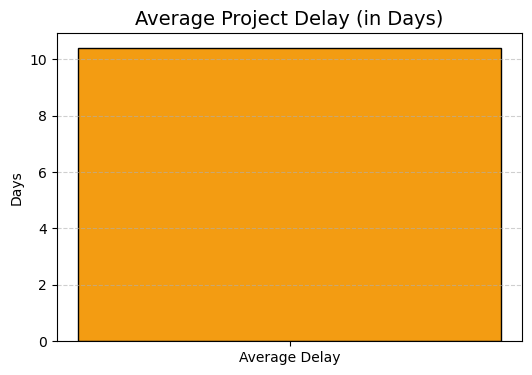

In [20]:
# ----------------------------------
# KPI 2: Average Delay Bar Chart
# ----------------------------------

import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))

plt.bar(
    ["Average Delay"],
    [average_delay],
    color="#f39c12",   # Orange = warning / delay
    edgecolor="black"
)

plt.title("Average Project Delay (in Days)", fontsize=14)
plt.ylabel("Days")
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.show()


### 📌 Insight: Average Project Delay

The analysis shows that projects are delayed by an average of **10.4 days** compared to their planned schedules.  
This indicates consistent deviations between estimated and actual timelines.

Such delays may be due to requirement changes, resource constraints, or inefficiencies in later SDLC phases such as deployment.  
Improving estimation accuracy and phase-wise monitoring can help reduce overall project delays.


## KPI 3: Project Type Delay Rate

This KPI analyzes delivery performance across different project types such as Web, Mobile, and Cloud.  
It helps determine whether certain project types are more prone to delivery delays than others.


In [21]:
# ----------------------------------
# KPI 3: Project Type Delay Rate
# ----------------------------------

project_type_delay = project_master.groupby("Project_Type").agg(
    Total_Projects=("Project_ID", "count"),
    Delayed_Projects=("Delivery_Status", lambda x: (x == "Delayed").sum())
).reset_index()

project_type_delay["Delay_Rate (%)"] = (
    project_type_delay["Delayed_Projects"] /
    project_type_delay["Total_Projects"]
) * 100

project_type_delay


,Project_Type,Total_Projects,Delayed_Projects,Delay_Rate (%)
0,Dashboard / Analytics,20,10,50.000000
1,Internal Tool,2,1,50.000000
2,Mobile Application,24,18,75.000000
3,Web Application,29,19,65.517241


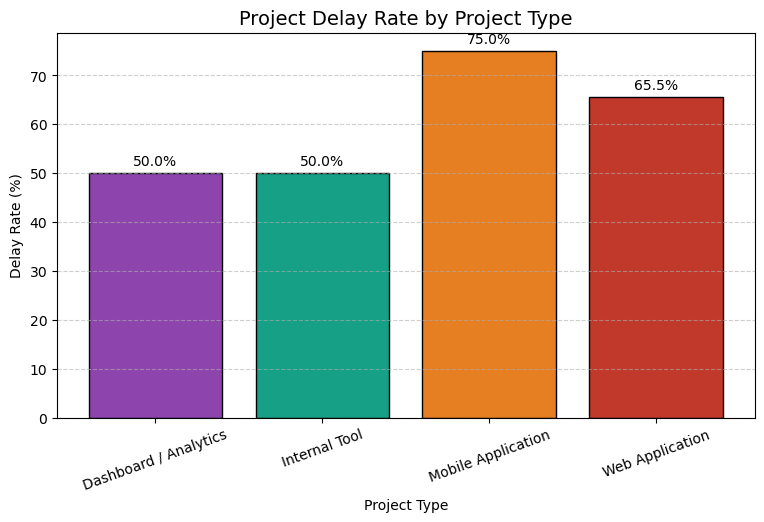

In [22]:
# ----------------------------------
# KPI 3: Project Type Delay Rate Visualization
# ----------------------------------

import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

colors = ["#8e44ad", "#16a085", "#e67e22", "#c0392b"]  
# Purple, Teal, Orange, Dark Red (increasing risk feel)

bars = plt.bar(
    project_type_delay["Project_Type"],
    project_type_delay["Delay_Rate (%)"],
    color=colors,
    edgecolor="black"
)

plt.title("Project Delay Rate by Project Type", fontsize=14)
plt.xlabel("Project Type")
plt.ylabel("Delay Rate (%)")
plt.xticks(rotation=20)
plt.grid(axis="y", linestyle="--", alpha=0.6)

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1,
        f"{height:.1f}%",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.show()


### 📌 Insight: Project Type Delay Rate

The analysis indicates that **Mobile Application projects experience the highest delay rate (75%)**, followed by **Web Applications (65.5%)**.  
In comparison, **Dashboard/Analytics** and **Internal Tool** projects show relatively lower delay rates (50%).

This suggests that customer-facing and technically complex projects, such as mobile and web applications, are more prone to schedule overruns.  
Higher integration complexity, frequent requirement changes, and testing challenges may contribute to these delays.

Project type should therefore be considered during planning to allocate appropriate buffers and resources.


## ⏱️ Section 3: Phase-Level Delay Analysis

This section examines project delays at the **SDLC phase level** to identify
where time overruns most frequently occur.
The objective is to move beyond overall delivery outcomes and pinpoint
specific phases that contribute the most to project delays.

At this stage, the analysis focuses on **process-level inefficiencies**
across Requirement, Design, Development, Testing, and Deployment phases,
without considering resource workload or managerial performance.


## KPI 4: Average Phase Delay (in Hours)

This KPI evaluates the average delay contributed by each SDLC phase by 
comparing planned effort with actual effort.

The objective is to identify which phases of the Software Development Life Cycle 
(Requirement, Design, Development, Testing, Deployment) contribute most to 
overall project schedule overruns.

At this stage, the analysis focuses strictly on phase-level performance 
without considering resource allocation or managerial influence.


In [23]:
# ----------------------------------
# KPI 4: Average Phase Delay (Hours)
# ----------------------------------

phase_delay = sdlc_phase_tracking.groupby("Phase_Name").agg(
    Planned_Avg_Hours=("Planned_Hours", "mean"),
    Actual_Avg_Hours=("Actual_Hours", "mean")
).reset_index()

phase_delay["Average_Delay_Hours"] = (
    phase_delay["Actual_Avg_Hours"] -
    phase_delay["Planned_Avg_Hours"]
)

phase_delay


,Phase_Name,Planned_Avg_Hours,Actual_Avg_Hours,Average_Delay_Hours
0,Deployment,136.133333,137.400000,1.266667
1,Design,135.253333,133.773333,-1.480000
2,Development,137.453333,135.480000,-1.973333
3,Requirement,139.653333,140.880000,1.226667
4,Testing,135.533333,134.666667,-0.866667


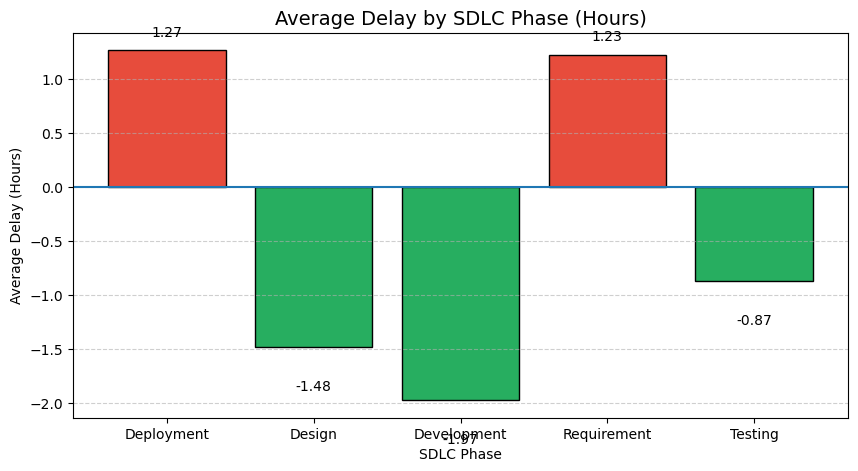

In [24]:
# ----------------------------------
# KPI 3: Average Phase Delay Visualization
# ----------------------------------

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

# Assign colors based on delay sign
colors = []
for value in phase_delay["Average_Delay_Hours"]:
    if value > 0:
        colors.append("#e74c3c")  # Red → delay
    else:
        colors.append("#27ae60")  # Green → early/efficient

bars = plt.bar(
    phase_delay["Phase_Name"],
    phase_delay["Average_Delay_Hours"],
    color=colors,
    edgecolor="black"
)

plt.title("Average Delay by SDLC Phase (Hours)", fontsize=14)
plt.xlabel("SDLC Phase")
plt.ylabel("Average Delay (Hours)")
plt.axhline(0)  # Neutral baseline
plt.grid(axis="y", linestyle="--", alpha=0.6)

# Value labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + (0.1 if height >= 0 else -0.3),
        f"{height:.2f}",
        ha="center",
        va="bottom" if height >= 0 else "top",
        fontsize=10
    )

plt.show()


### 📌 Insight: Phase-Level Delay Contribution

The analysis shows that **Deployment (1.27 hours)** and **Requirement (1.23 hours)** 
phases exhibit positive average delays, indicating schedule overruns at the 
beginning and end stages of the SDLC.

In contrast, **Design (-1.48 hours)**, **Development (-1.97 hours)**, and 
**Testing (-0.87 hours)** phases show slight negative delays, suggesting that 
these phases are generally completed within or slightly before planned effort.

This pattern suggests that delays are not primarily caused by core development 
activities, but rather by requirement clarification and deployment execution.  
Improving requirement validation early in the project and strengthening 
deployment planning may help reduce overall delivery delays.


## 👥 Section 4: Resource Utilization Analysis

This section examines resource allocation patterns to understand whether 
workload imbalance contributes to project delivery delays.

The objective is to analyze role-level overutilization, workload distribution, 
and multi-project assignments to determine whether resource pressure is a 
potential root cause of schedule overruns.

At this stage, the analysis focuses on resource effort patterns and their 
relationship with delivery outcomes, without evaluating managerial performance.


## KPI 5: Resource Overutilization Rate

This KPI measures the percentage of resource assignments where actual effort 
exceeded planned effort.

The objective is to identify the extent of workload pressure across resources 
and determine whether overutilization is a common occurrence within projects.

At this stage, the analysis focuses strictly on resource effort comparison 
without linking it to project delay outcomes.


In [25]:
# ----------------------------------
# KPI 5: Resource Overutilization Rate
# ----------------------------------

total_allocations = resource_allocation.shape[0]

overutilized_allocations = resource_allocation[
    resource_allocation["Actual_Hours"] >
    resource_allocation["Planned_Hours"]
].shape[0]

overutilization_rate = (overutilized_allocations / total_allocations) * 100

total_allocations, overutilized_allocations, overutilization_rate


(656, 305, 46.493902439024396)

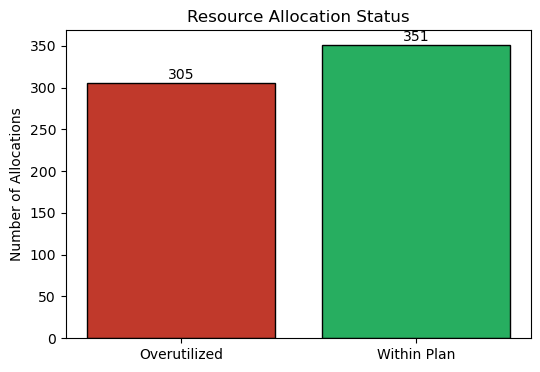

In [26]:
# ----------------------------------
# KPI 5: Resource Overutilization Visualization (Simplified)
# ----------------------------------

import matplotlib.pyplot as plt

categories = ["Overutilized", "Within Plan"]
values = [overutilized_allocations, total_allocations - overutilized_allocations]

plt.figure(figsize=(6, 4))

bars = plt.bar(categories, values,
               color=["#c0392b", "#27ae60"],
               edgecolor="black")

plt.title("Resource Allocation Status")
plt.ylabel("Number of Allocations")

# Add value labels
for i in range(len(values)):
    plt.text(i, values[i] + 5, values[i], ha='center')

plt.show()


### 📌 Insight: Resource Overutilization

Out of 656 total resource allocations, 305 instances (46.49%) exceeded 
planned effort.

This indicates that nearly half of the resource assignments experience 
workload pressure, which may increase the risk of delays and quality issues.

High overutilization suggests the need for improved effort estimation, 
balanced workload distribution, and proactive monitoring of resource capacity.


## KPI 6: Delay Rate for Overutilized Projects

This KPI evaluates whether projects experiencing resource overutilization 
have a higher likelihood of delivery delays.

The objective is to examine the relationship between workload pressure 
and project schedule performance.

At this stage, the analysis links resource allocation data with 
project delivery status to assess potential delay risk.


In [27]:
# ----------------------------------
# KPI 6: Delay Rate for Overutilized Projects
# ----------------------------------

# Step 1: Identify overutilized project IDs
overutilized_projects = resource_allocation[
    resource_allocation["Actual_Hours"] > resource_allocation["Planned_Hours"]
]["Project_ID"].unique()

# Step 2: Create flag in project_master
project_master["Overutilized_Flag"] = project_master["Project_ID"].isin(overutilized_projects)

# Step 3: Calculate delay rate for both groups
kpi6 = project_master.groupby("Overutilized_Flag").agg(
    Total_Projects=("Project_ID", "count"),
    Delayed_Projects=("Delivery_Status", lambda x: (x == "Delayed").sum())
).reset_index()

kpi6["Delay_Rate (%)"] = (
    kpi6["Delayed_Projects"] / kpi6["Total_Projects"]
) * 100

kpi6


,Overutilized_Flag,Total_Projects,Delayed_Projects,Delay_Rate (%)
0,False,3,3,100.0
1,True,72,45,62.5


In [28]:
project_master.shape


(75, 15)

In [29]:
project_master["Project_ID"].nunique()


75

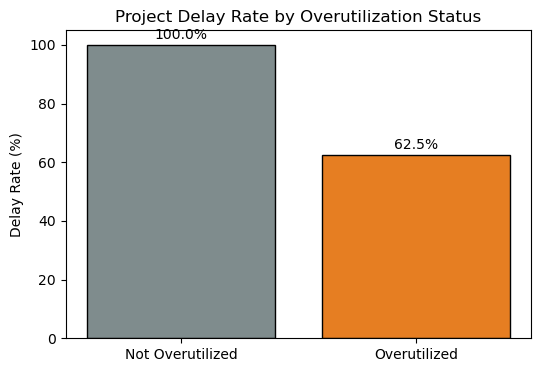

In [30]:
# ----------------------------------
# KPI 6: Delay Rate by Overutilization Status
# ----------------------------------

import matplotlib.pyplot as plt

categories = ["Not Overutilized", "Overutilized"]
values = kpi6["Delay_Rate (%)"]

plt.figure(figsize=(6, 4))

bars = plt.bar(categories, values,
               color=["#7f8c8d", "#e67e22"],   # Grey vs Orange
               edgecolor="black")

plt.title("Project Delay Rate by Overutilization Status")
plt.ylabel("Delay Rate (%)")

# Add value labels
for i in range(len(values)):
    plt.text(i, values.iloc[i] + 2, f"{values.iloc[i]:.1f}%", ha='center')

plt.show()


### 📌 Insight: Delay Rate for Overutilized Projects

Among 75 total projects, 72 experienced at least one instance of resource overutilization, 
indicating that workload pressure is widespread.

Projects with overutilization show a delay rate of **62.5%**, while the small group 
without overutilization (3 projects) shows a 100% delay rate. However, due to the 
very small sample size of non-overutilized projects, this comparison should be 
interpreted cautiously.

The key observation is that overutilization is highly prevalent across projects, 
suggesting that workload imbalance may be a systemic issue within the organization.


## 📊 KPI 7: Average Projects Assigned per Resource

This KPI measures how many unique projects are assigned to each resource 
on average. The objective is to evaluate workload distribution and 
identify whether employees are handling multiple projects simultaneously.

This analysis focuses on allocation spread rather than hours, 
helping assess multitasking intensity across the organization.


In [31]:
# Count unique projects per resource
projects_per_resource = (
    resource_allocation.groupby("Resource_ID")["Project_ID"]
    .nunique()
    .reset_index(name="Project_Count")
)

projects_per_resource.head()


,Resource_ID,Project_Count
0,EMP001,21
1,EMP002,27
2,EMP003,24
3,EMP004,26
4,EMP005,22


In [32]:
avg_projects_per_resource = projects_per_resource["Project_Count"].mean()

total_resources = projects_per_resource.shape[0]

print("Total Resources:", total_resources)
print("Average Projects per Resource:", round(avg_projects_per_resource, 2))


Total Resources: 30
Average Projects per Resource: 20.57


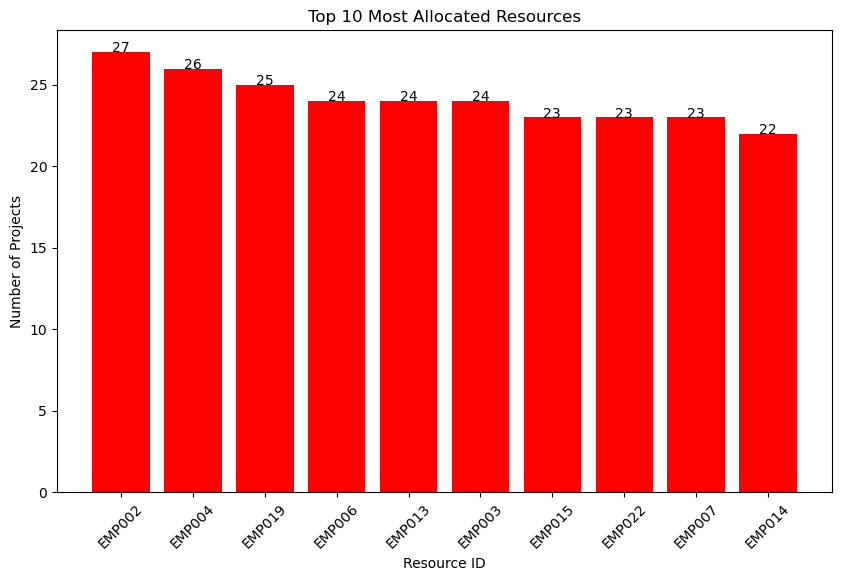

In [33]:
import matplotlib.pyplot as plt

# Sort and take top 10
top_resources = projects_per_resource.sort_values(
    by="Project_Count", ascending=False
).head(10)

plt.figure(figsize=(10,6))

bars = plt.bar(
    top_resources["Resource_ID"],
    top_resources["Project_Count"],
    color="red"
    
)

# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        str(height),
        ha='center'
    )

plt.title("Top 10 Most Allocated Resources")
plt.xlabel("Resource ID")
plt.ylabel("Number of Projects")
plt.xticks(rotation=45)

plt.show()


### 📌 Insight:

The average projects handled per resource is **20.57**, indicating a high workload distribution across the organization.

From the visualization, certain resources are assigned to significantly more projects than others. This suggests potential workload imbalance and possible risk of resource overutilization.

Such concentration of assignments may impact productivity, increase burnout risk, and indirectly contribute to project delays.

Further analysis should evaluate whether highly allocated resources are associated with higher delay rates.


## 📊 KPI: Workload vs Project Delay Relationship

This KPI examines whether higher resource workload (number of projects handled per resource) is associated with increased project delays.

The objective is to determine if workload imbalance is contributing to delivery inefficiencies.

This shifts the analysis from descriptive metrics to potential root-cause investigation.

In [34]:
# ----------------------------------
# Cell: Resource Workload vs Delay Mapping
# ----------------------------------

# Merge resource allocation with project delivery status
resource_delay = resource_allocation.merge(
    project_master[["Project_ID", "Delivery_Status"]],
    on="Project_ID",
    how="left"
)

# Convert Delivery_Status into numeric flag
resource_delay["Delayed_Flag"] = resource_delay["Delivery_Status"].apply(
    lambda x: 1 if x.strip() == "Delayed" else 0
)

resource_delay.head()


,Resource_ID,Project_ID,Role,Phase_Assigned,Planned_Hours,Actual_Hours,Utilization_Status,Delivery_Status,Delayed_Flag
0,EMP005,HELSY001,BA,Requirement,174,153,Underutilized,On Time,0
1,EMP008,HELSY001,Developer,Design,49,43,Underutilized,On Time,0
2,EMP011,HELSY001,Developer,Design,49,43,Underutilized,On Time,0
3,EMP013,HELSY001,Developer,Design,49,43,Underutilized,On Time,0
4,EMP017,HELSY001,Developer,Development,27,24,Underutilized,On Time,0


In [35]:
# ----------------------------------
# Cell: Workload vs Delay Summary
# ----------------------------------

resource_summary = resource_delay.groupby("Resource_ID").agg(
    Total_Projects=("Project_ID", "nunique"),
    Delayed_Projects=("Delayed_Flag", "sum")
).reset_index()

resource_summary["Delay_Rate (%)"] = (
    resource_summary["Delayed_Projects"] /
    resource_summary["Total_Projects"]
) * 100

resource_summary.head()


,Resource_ID,Total_Projects,Delayed_Projects,Delay_Rate (%)
0,EMP001,21,16,76.190476
1,EMP002,27,14,51.851852
2,EMP003,24,18,75.000000
3,EMP004,26,18,69.230769
4,EMP005,22,11,50.000000


## 📊 KPI: Resource Workload vs Project Delay Rate

This KPI analyzes whether higher resource workload is associated with 
higher project delay rates.

The objective is to understand if overburdened resources contribute 
to delivery risk and to identify workload imbalance patterns 
that may be affecting project timelines.


In [36]:
# ----------------------------------
# Cell: Sort Resources by Delay Rate
# ----------------------------------

resource_summary_sorted = resource_summary.sort_values(
    by="Delay_Rate (%)",
    ascending=False
)

resource_summary_sorted.head(10)


,Resource_ID,Total_Projects,Delayed_Projects,Delay_Rate (%)
9,EMP010,15,12,80.000000
7,EMP008,20,16,80.000000
13,EMP014,22,17,77.272727
0,EMP001,21,16,76.190476
2,EMP003,24,18,75.000000
20,EMP021,20,15,75.000000
29,EMP030,19,14,73.684211
28,EMP029,15,11,73.333333
15,EMP016,22,16,72.727273
17,EMP018,18,13,72.222222


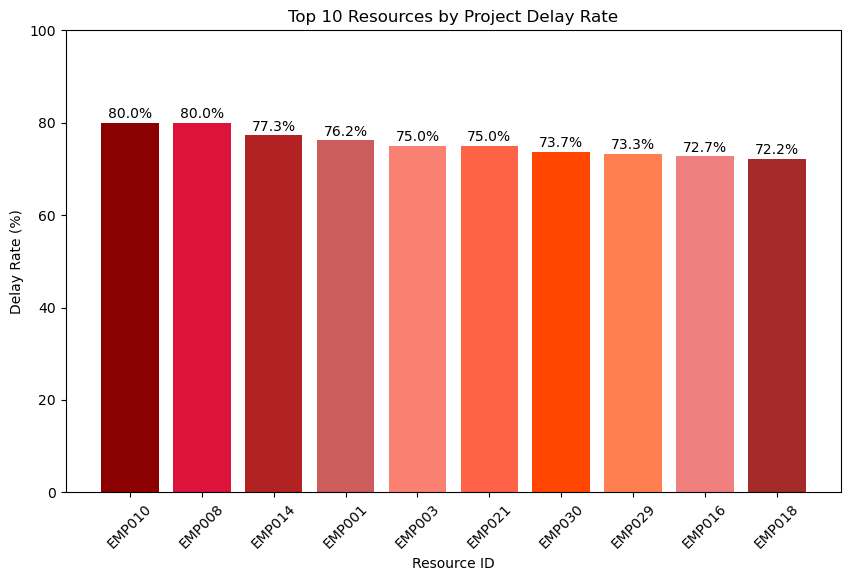

In [37]:
# ----------------------------------
# Cell: KPI 11 Graph – Top 10 Resources by Delay Rate
# ----------------------------------

import matplotlib.pyplot as plt

top10 = resource_summary_sorted.head(10)

plt.figure(figsize=(10,6))

bars = plt.bar(
    top10["Resource_ID"],
    top10["Delay_Rate (%)"],
    color=[
        "darkred", "crimson", "firebrick", "indianred", "salmon",
        "tomato", "orangered", "coral", "lightcoral", "brown"
    ]
)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 1,
        f"{height:.1f}%",
        ha='center'
    )

plt.title("Top 10 Resources by Project Delay Rate")
plt.xlabel("Resource ID")
plt.ylabel("Delay Rate (%)")
plt.xticks(rotation=45)
plt.ylim(0, 100)

plt.show()


### 🔎 Insight

The visualization highlights a significant variation in delay rates across resources.

Several resources (e.g., EMP010 and EMP008) exhibit delay rates as high as 80%, 
indicating that a large proportion of the projects they were assigned to were delayed.

A noticeable pattern is that many high-delay resources are handling a 
moderately high number of projects, suggesting potential workload imbalance 
or allocation inefficiencies.

This analysis indicates that project delays may not only be phase-related 
but could also be influenced by uneven resource workload distribution.

Further investigation into workload optimization and balanced allocation 
strategies is recommended to improve overall project delivery performance.


In [38]:
sdlc_phase_tracking.head()

,Project_ID,Phase_Name,Phase_Start_Date,Phase_End_Date,Planned_Hours,Actual_Hours,Phase_Owner_ID,Phase_Status,Phase_Delay_Flag,Rework_Required
0,HELSY001,Requirement,2022-05-17,2022-06-14,174,153,BA,Completed,No,No
1,HELSY001,Design,2022-06-15,2022-06-29,149,130,Developer,Completed,No,No
2,HELSY001,Development,2022-06-30,2022-08-30,83,72,Developer,Completed,No,No
3,HELSY001,Testing,2022-08-31,2022-03-10,157,134,Tester,Completed,No,No
4,HELSY001,Deployment,2022-04-10,2022-10-26,163,172,Lead/Developer,Completed,Yes,No


In [39]:
# ----------------------------------
# Cell: Create Project-Level Rework Flag
# ----------------------------------

# Convert Yes/No to numeric
sdlc_phase_tracking["Rework_Flag"] = (
    sdlc_phase_tracking["Rework_Required"].str.strip() == "Yes"
).astype(int)

# Check if project had any rework
project_rework = sdlc_phase_tracking.groupby("Project_ID")["Rework_Flag"].max().reset_index()

project_rework.head()


,Project_ID,Rework_Flag
0,HELSY001,0
1,HELSY002,0
2,HELSY003,1
3,HELSY004,0
4,HELSY005,0


In [40]:
# ----------------------------------
# Cell: Merge Rework with Project Master
# ----------------------------------

project_master = project_master.merge(
    project_rework,
    on="Project_ID",
    how="left"
)

project_master.head()


,Project_ID,Project_Name,Business_Domain,Project_Type,Client_Type,Project_Manager_ID,Team_Size,Project_Start_Date,Project_End_Date,Project_Status,Planned_Duration_Days,Actual_Duration_Days,Delivery_Status,Project_Delay_Days,Overutilized_Flag,Rework_Flag
0,HELSY001,HR Recruitment Portal,Retail,Web Application,External,PM03,8,2022-05-17,2022-11-09,Completed,117,117,On Time,0,True,0
1,HELSY002,Internal HR Tool,Retail,Internal Tool,Internal,PM01,8,2024-04-24,2024-04-10,Completed,168,163,On Time,-5,True,0
2,HELSY003,Retail POS System,Retail,Web Application,External,PM01,4,2024-02-24,2024-08-07,Completed,110,135,Delayed,25,True,1
3,HELSY004,Inventory Management System,Healthcare,Mobile Application,External,PM03,7,2021-01-14,2021-09-05,Completed,100,115,Delayed,15,True,0
4,HELSY005,E-commerce Web Platform,Logistics,Web Application,External,PM03,4,2021-07-29,2021-04-11,Completed,83,98,Delayed,15,True,0


In [41]:
# ----------------------------------
# Cell: Rework vs Delay Rate
# ----------------------------------

rework_summary = project_master.groupby("Rework_Flag").agg(
    Total_Projects=("Project_ID", "count"),
    Delayed_Projects=("Delivery_Status", lambda x: (x.str.strip() != "On Time").sum())
).reset_index()

rework_summary["Delay_Rate (%)"] = (
    rework_summary["Delayed_Projects"] / rework_summary["Total_Projects"]
) * 100

rework_summary


,Rework_Flag,Total_Projects,Delayed_Projects,Delay_Rate (%)
0,0,51,32,62.745098
1,1,24,16,66.666667


### 🔎 Insight

Projects that required rework show a slightly higher delay rate (66.7%) 
compared to projects without rework (62.7%).

However, the difference is relatively small (~4%), indicating that while 
rework contributes to delays, it may not be the primary driver of project 
delivery issues.

This suggests that other factors such as workload distribution, 
resource allocation, or phase-level inefficiencies may have a stronger 
impact on overall delivery performance.


## 📊 Section 5: Project Manager Effectiveness

This section evaluates delivery performance from a leadership perspective. 
After analyzing phase-level delays and resource utilization patterns, 
it is important to assess how effectively Project Managers oversee and 
deliver their assigned projects.

The objective is to examine managerial consistency in achieving on-time 
delivery and to understand whether workload influences leadership performance.


### 📌 KPI 8: Project Manager On-Time Delivery Rate

This KPI evaluates how effectively each Project Manager delivers projects 
within the planned timeline.

The objective is to identify managers who consistently achieve on-time 
delivery and to assess variations in delivery performance across leadership.


In [42]:
# ----------------------------------
# KPI 8: PM On-Time Delivery Rate
# ----------------------------------

pm_performance = project_master.groupby("Project_Manager_ID").agg(
    Total_Projects=("Project_ID", "count"),
    On_Time_Projects=("Delivery_Status", lambda x: (x.str.strip() == "On Time").sum())
).reset_index()

pm_performance["On_Time_Rate (%)"] = (
    pm_performance["On_Time_Projects"] / pm_performance["Total_Projects"]
) * 100

pm_performance.sort_values(by="On_Time_Rate (%)", ascending=False)


,Project_Manager_ID,Total_Projects,On_Time_Projects,On_Time_Rate (%)
0,PM01,22,10,45.454545
1,PM02,22,9,40.909091
3,PM04,10,3,30.000000
2,PM03,21,5,23.809524


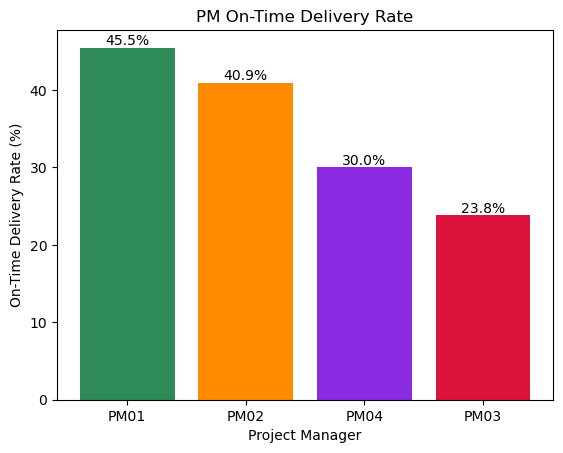

In [43]:
import matplotlib.pyplot as plt

# Sort for better visualization
pm_performance_sorted = pm_performance.sort_values(
    by="On_Time_Rate (%)", ascending=False
)

plt.figure()

bars = plt.bar(
    pm_performance_sorted["Project_Manager_ID"],
    pm_performance_sorted["On_Time_Rate (%)"],
    color=["#2E8B57", "#FF8C00", "#8A2BE2", "#DC143C"]
)

# Value labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.1f}%",
        ha='center',
        va='bottom'
    )

plt.title("PM On-Time Delivery Rate")
plt.xlabel("Project Manager")
plt.ylabel("On-Time Delivery Rate (%)")

plt.show()


### 🔎 Insight

PM01 demonstrates the highest on-time delivery rate (45.5%), 
indicating comparatively stronger schedule adherence.

PM02 follows closely at 40.9%, suggesting moderate delivery stability.

PM04 (30%) and PM03 (23.8%) show significantly lower on-time rates, 
indicating potential challenges in schedule control or project complexity.

Overall, no Project Manager exceeds 50% on-time performance, 
suggesting that delivery delays may be influenced by broader 
organizational or structural factors rather than individual leadership alone.


### 📌 KPI 9: Average Delay by Project Manager Workload

This KPI evaluates whether the number of projects handled by a 
Project Manager impacts delivery performance.

The objective is to determine if higher managerial workload 
is associated with increased project delays.


In [44]:
# ----------------------------------
# KPI 9: PM Workload vs Delay
# ----------------------------------

# Step 1: Create delayed flag
project_master["Delayed_Flag"] = (
    project_master["Delivery_Status"].str.strip() != "On Time"
).astype(int)

# Step 2: Calculate PM workload and delay rate
pm_workload = project_master.groupby("Project_Manager_ID").agg(
    Total_Projects=("Project_ID", "count"),
    Delayed_Projects=("Delayed_Flag", "sum")
).reset_index()

pm_workload["Delay_Rate (%)"] = (
    pm_workload["Delayed_Projects"] / pm_workload["Total_Projects"]
) * 100

pm_workload.sort_values(by="Total_Projects", ascending=False)


,Project_Manager_ID,Total_Projects,Delayed_Projects,Delay_Rate (%)
0,PM01,22,12,54.545455
1,PM02,22,13,59.090909
2,PM03,21,16,76.190476
3,PM04,10,7,70.000000


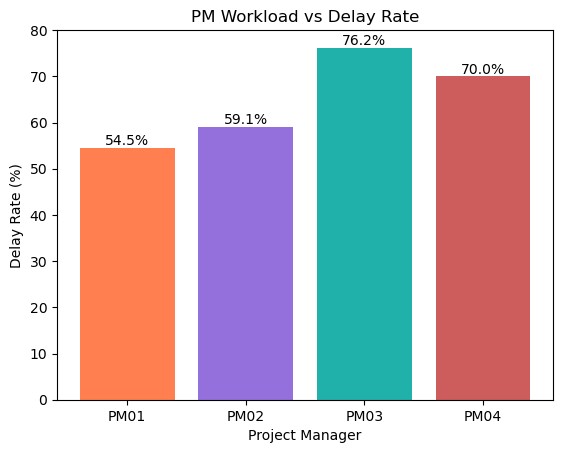

In [45]:
import matplotlib.pyplot as plt

# Sort by workload for logical viewing
pm_workload_sorted = pm_workload.sort_values(
    by="Total_Projects", ascending=False
)

plt.figure()

bars = plt.bar(
    pm_workload_sorted["Project_Manager_ID"],
    pm_workload_sorted["Delay_Rate (%)"],
    color=["#FF7F50", "#9370DB", "#20B2AA", "#CD5C5C"]
)

# Value labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.1f}%",
        ha='center',
        va='bottom'
    )

plt.title("PM Workload vs Delay Rate")
plt.xlabel("Project Manager")
plt.ylabel("Delay Rate (%)")

plt.show()


### 🔎 Insight

PM01 and PM02 handle the highest number of projects (22 each) 
and exhibit moderate delay rates (~55–59%).

PM03, despite handling a similar workload (21 projects), 
shows the highest delay rate (76.2%), indicating possible 
delivery inefficiencies beyond workload alone.

PM04 manages the lowest workload (10 projects) 
but still experiences a high delay rate (70%), 
suggesting that lower workload does not necessarily 
guarantee better delivery performance.

Overall, delay performance appears influenced by 
factors beyond just managerial workload, such as 
project complexity, resource allocation, or phase risks.


## 📊 Section 6: Time & Trend Analysis

This section evaluates project delivery performance from a 
long-term strategic perspective.

After analyzing delivery outcomes, phase delays, resource utilization, 
and managerial effectiveness, it is essential to examine 
whether organizational performance is improving over time.

The objective is to identify year-over-year trends in 
delivery efficiency, project size, and complexity.


### 📌 KPI 10: Year-over-Year On-Time Delivery Rate

This KPI measures the trend of on-time delivery performance 
across different years.

The objective is to determine whether project delivery 
efficiency is improving, declining, or remaining stable over time.


In [46]:
# ----------------------------------
# KPI 10: Year-over-Year On-Time Delivery
# ----------------------------------

# Ensure datetime format
project_master["Project_Start_Date"] = pd.to_datetime(
    project_master["Project_Start_Date"]
)

# Extract year
project_master["Year"] = project_master["Project_Start_Date"].dt.year

# Create delayed flag
project_master["Delayed_Flag"] = (
    project_master["Delivery_Status"].str.strip() != "On Time"
).astype(int)

# Group by Year
yoy_performance = project_master.groupby("Year").agg(
    Total_Projects=("Project_ID", "count"),
    Delayed_Projects=("Delayed_Flag", "sum")
).reset_index()

yoy_performance["On_Time_Rate (%)"] = (
    (yoy_performance["Total_Projects"] - yoy_performance["Delayed_Projects"])
    / yoy_performance["Total_Projects"]
) * 100

yoy_performance.sort_values("Year")


,Year,Total_Projects,Delayed_Projects,On_Time_Rate (%)
0,2021,17,12,29.411765
1,2022,16,9,43.750000
2,2023,19,10,47.368421
3,2024,19,14,26.315789
4,2025,4,3,25.000000


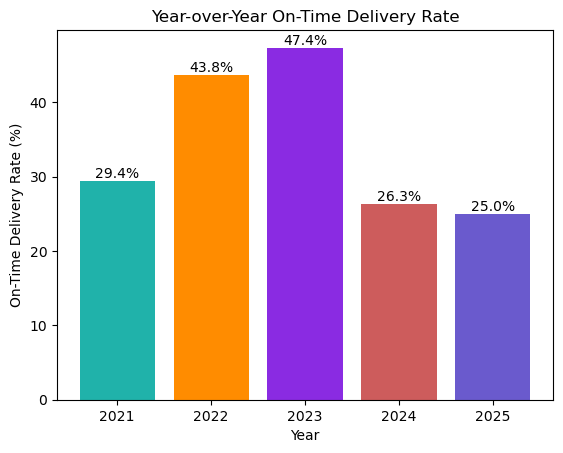

In [47]:
import matplotlib.pyplot as plt

plt.figure()

bars = plt.bar(
    yoy_performance["Year"].astype(str),
    yoy_performance["On_Time_Rate (%)"],
    color=["#20B2AA", "#FF8C00", "#8A2BE2", "#CD5C5C", "#6A5ACD"]
)

# Value labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.1f}%",
        ha='center',
        va='bottom'
    )

plt.title("Year-over-Year On-Time Delivery Rate")
plt.xlabel("Year")
plt.ylabel("On-Time Delivery Rate (%)")

plt.show()


### 🔎 Insight

On-time delivery performance improved from 29.4% in 2021 
to a peak of 47.4% in 2023, indicating gradual operational 
improvement during this period.

However, performance declined significantly in 2024 (26.3%) 
and remained low in 2025 (25%), suggesting emerging 
delivery challenges.

The decline in recent years may indicate increasing 
project complexity, resource strain, or process inefficiencies.

Overall, while mid-period improvement was observed, 
recent trends highlight the need for strategic intervention 
to stabilize delivery performance.


### 📌 KPI 11: Average Team Size & Project Duration by Year

This KPI evaluates whether projects are becoming larger 
and more time-intensive over the years.

The objective is to assess trends in team size and 
project duration to understand increasing complexity 
and its potential impact on delivery performance.


In [48]:
# ----------------------------------
# KPI 11: Avg Team Size & Duration by Year
# ----------------------------------

complexity_trend = project_master.groupby("Year").agg(
    Avg_Team_Size=("Team_Size", "mean"),
    Avg_Project_Duration=("Actual_Duration_Days", "mean")
).reset_index()

complexity_trend.sort_values("Year")


,Year,Avg_Team_Size,Avg_Project_Duration
0,2021,5.352941,133.588235
1,2022,5.312500,134.875000
2,2023,5.526316,150.421053
3,2024,5.842105,143.052632
4,2025,6.500000,166.750000


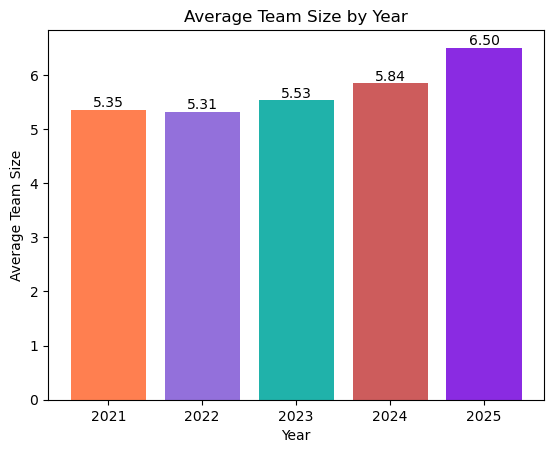

In [49]:
import matplotlib.pyplot as plt

plt.figure()

bars = plt.bar(
    complexity_trend["Year"].astype(str),
    complexity_trend["Avg_Team_Size"],
    color=["#FF7F50", "#9370DB", "#20B2AA", "#CD5C5C", "#8A2BE2"]
)

# Value labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.2f}",
        ha='center',
        va='bottom'
    )

plt.title("Average Team Size by Year")
plt.xlabel("Year")
plt.ylabel("Average Team Size")

plt.show()


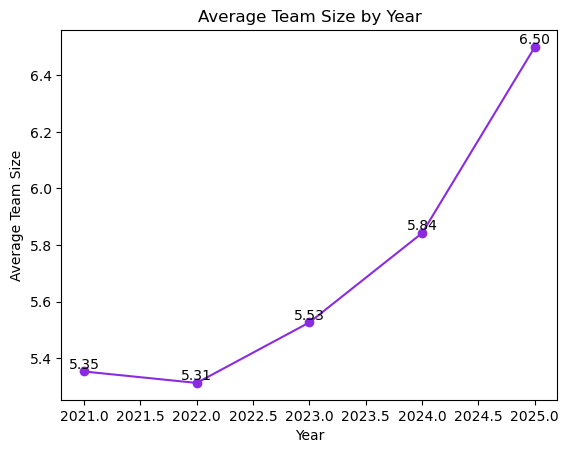

In [50]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(
    complexity_trend["Year"],
    complexity_trend["Avg_Team_Size"],
    marker="o",
    color="#8A2BE2"
)

# Value labels
for i in range(len(complexity_trend)):
    plt.text(
        complexity_trend["Year"][i],
        complexity_trend["Avg_Team_Size"][i],
        f"{complexity_trend['Avg_Team_Size'][i]:.2f}",
        ha='center',
        va='bottom'
    )

plt.title("Average Team Size by Year")
plt.xlabel("Year")
plt.ylabel("Average Team Size")

plt.show()

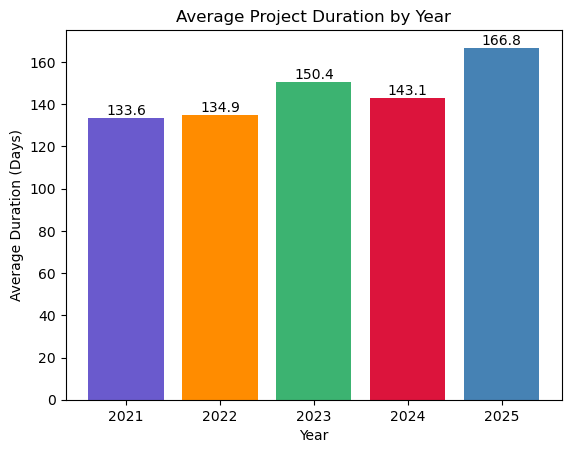

In [51]:
plt.figure()

bars = plt.bar(
    complexity_trend["Year"].astype(str),
    complexity_trend["Avg_Project_Duration"],
    color=["#6A5ACD", "#FF8C00", "#3CB371", "#DC143C", "#4682B4"]
)

# Value labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.1f}",
        ha='center',
        va='bottom'
    )

plt.title("Average Project Duration by Year")
plt.xlabel("Year")
plt.ylabel("Average Duration (Days)")

plt.show()


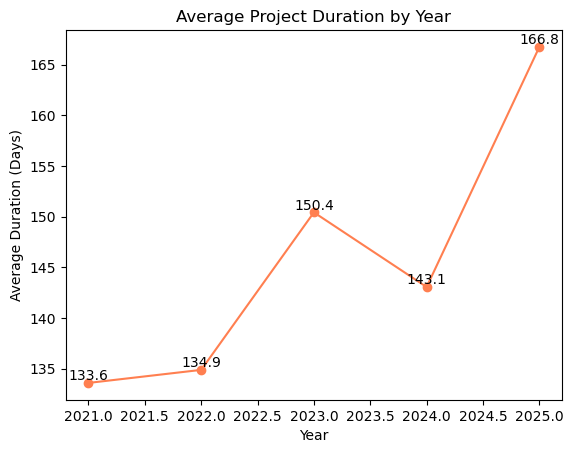

In [52]:
plt.figure()

plt.plot(
    complexity_trend["Year"],
    complexity_trend["Avg_Project_Duration"],
    marker="o",
    color="#FF7F50"
)

# Value labels
for i in range(len(complexity_trend)):
    plt.text(
        complexity_trend["Year"][i],
        complexity_trend["Avg_Project_Duration"][i],
        f"{complexity_trend['Avg_Project_Duration'][i]:.1f}",
        ha='center',
        va='bottom'
    )

plt.title("Average Project Duration by Year")
plt.xlabel("Year")
plt.ylabel("Average Duration (Days)")

plt.show()


### 🔎 Insight

Average team size shows a gradual upward trend from 2021 (5.35) 
to 2025 (6.50), indicating increasing workforce allocation per project.

Project duration increased significantly in 2023 and peaks in 2025 
(166.8 days), suggesting rising project complexity or scope expansion.

The simultaneous increase in team size and project duration 
in recent years indicates growing organizational complexity.

Combined with declining on-time delivery performance in 2024–2025, 
this suggests that scaling project size may be contributing 
to increased delivery risk.

Strategic process optimization and improved workload planning 
may be required to stabilize performance.


## 📊 Executive Summary

This analysis evaluated Software Development Lifecycle (SDLC) efficiency 
across multiple dimensions, including delivery performance, phase-level delays, 
resource utilization, managerial effectiveness, and year-over-year trends.

Key Findings:

• Overall on-time delivery rate stands at 36%, indicating that the majority of projects experience schedule overruns.

• Deployment and Requirement phases show positive average delay hours, 
suggesting higher risk in early planning and final release stages.

• Mobile Applications exhibit the highest delay rate (75%), 
indicating increased complexity or resource strain in this project type.

• Resource overutilization is significant, with 46.5% of allocations exceeding optimal levels, 
contributing to delivery instability.

• Managerial performance varies, with no Project Manager achieving above 50% 
consistent on-time delivery.

• Year-over-year performance improved until 2023 but declined sharply in 2024–2025, 
indicating emerging operational challenges.

• Project complexity is increasing, reflected by rising average team size 
and longer project durations in recent years.

Overall, the organization demonstrates structured SDLC processes, 
but delivery efficiency remains inconsistent due to workload pressure, 
phase bottlenecks, and increasing project complexity.


## 📄 Final Conclusion

The analysis reveals that project delivery inefficiencies are not driven 
by a single factor but rather by a combination of structural and operational challenges.

Key observations indicate:

• Early-stage requirement clarity and deployment execution require process strengthening.
• Resource overutilization contributes significantly to delay risk.
• Increasing project size and duration signal rising organizational complexity.
• Managerial workload alone does not fully explain delay patterns, 
  suggesting systemic process inefficiencies.

Strategic Recommendations:

1. Implement stricter workload balancing mechanisms to reduce resource overutilization.
2. Introduce early requirement validation checkpoints to reduce downstream rework.
3. Strengthen deployment planning and release governance.
4. Monitor high-risk project types (e.g., Mobile Applications) with enhanced oversight.
5. Establish periodic performance reviews based on trend analytics.

In conclusion, while the organization shows maturity in structured SDLC execution, 
improving workload distribution, phase governance, and strategic planning 
will be critical to stabilizing delivery performance and sustaining long-term efficiency.
